In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Clone your collaboration repository
# Replace with your actual GitHub URL
!git clone https://github.com/nmorok/Teleconnections-ViT.git

# 2. Enter the repository directory
import os
os.chdir('Teleconnections-ViT')
# 3. Add the current directory to sys.path so 'import model' works
import sys
sys.path.append(os.getcwd())

# 4. Verify the files are present
print("Files in current directory:", os.listdir())

Cloning into 'Teleconnections-ViT'...
remote: Enumerating objects: 161, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 161 (delta 9), reused 20 (delta 5), pack-reused 132 (from 1)
Receiving objects: 100% (161/161), 149.55 MiB | 35.60 MiB/s, done.
Resolving deltas: 100% (53/53), done.
Updating files: 100% (33/33), done.
Files in current directory: ['.git', 'Pipeline.md', 'LICENSE', '.gitignore', 'requirements.txt', 'data', 'notebook', 'README.md', 'models', 'test_attention.png']


In [4]:


from google.colab import drive
import torch


# 2. Define your data path (Update this to your actual Drive folder)
# Usually formatted as: /content/drive/MyDrive/Folder_Name
DATA_PATH = '/content/drive/MyDrive/Teleconnection_ViT'

# 3. Quick verification check
if os.path.exists(DATA_PATH):
    print(f"✓ Data folder found at: {DATA_PATH}")
    print("Files available:", os.listdir(DATA_PATH))
else:
    print(f"✗ ERROR: Could not find folder at {DATA_PATH}. Check your Drive path.")

# 4. Hardware Check
# 1. Check if CUDA (GPU support) is available
print(f"Is CUDA available? {torch.cuda.is_available()}")

# 2. Get the name of the GPU assigned by Colab Pro
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_tensor_details_device(0)}")
else:
    print("WARNING: Using CPU. Check your Colab Runtime settings.")

✓ Data folder found at: /content/drive/MyDrive/Teleconnection_ViT
Files available: ['checkpoints', 'val_spawners.npy', 'train_spawners.npy', 'test_spawners.npy', 'test_recruits.npy', 'val_recruits.npy', 'train_recruits.npy']
Is CUDA available? True
GPU Name: NVIDIA A100-SXM4-80GB


AttributeError: module 'torch.cuda' has no attribute 'get_tensor_details_device'

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from models.model import CrabTransformer
from models.losses import TweedieLoss
from data.data_helper import CrabDataset

In [39]:
def train_model():

    # set hyperparameters:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")
    batch_size = 5
    epochs = 50
    learning_rate = 1e-4
    grid_size = 50
    patch_size = 5
    in_channels = 1
    embed_dim = 128
    num_heads = 8
    d_ff = 512
    num_layers = 6
    mask = None
    dropout = 0.1

    weight_decay = 1e-5
    max_grad_norm = 1

    patience = 15  # Number of epochs to wait for improvement
    min_delta = 1e-4  # Minimum change to qualify as improvement

    # Create checkpoint directory in Google Drive
    CHECKPOINT_DIR = os.path.join(DATA_PATH, "checkpoints")
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")

    # prepare data
    train_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "train_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "train_recruits.npy"),
        n_years=30
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    val_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "val_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "val_recruits.npy"),
        n_years=30
    )

    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # initialize the model, loss, and optimizer
    model = CrabTransformer(grid_size, patch_size, in_channels, embed_dim, num_heads, num_layers, d_ff, mask, dropout).to(device)
    #criterion = TweedieLoss(power=1.5)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    from torch.optim.lr_scheduler import ReduceLROnPlateau
    scheduler = ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5,
        patience=10
    )

    # Initialize best validation loss tracker
    best_val_loss = float('inf')
    epochs_no_improve = 0
    early_stop = False
    final_epoch = 0


    # training loop

    for epoch in range(epochs):
        if early_stop:
            print("Early stopping triggered.")
            print(f"Training stopped after {epoch} epochs.")
            print(f"Best Val Loss: {best_val_loss:.4f}")
            break

        # --- TRAINING PHASE ---
        model.train() # Set model to training mode
        total_train_loss = 0
        epoch_grad_norms = []
        for batch_idx, (inputs, targets, year_indices) in enumerate(train_loader):
            # 'data' is already the [Batch, 2, 50, 50] tensor
            # 'target' is the [Batch, 1, 50, 50] recruitment density
            inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)

            # clear the gradients
            optimizer.zero_grad()
            # forward pass
            outputs = model(inputs, year_indices)  # [batch_size, 1, 50, 50]
            # calculate loss
            loss = criterion(outputs, targets)
            # backward pass (calculate gradients)
            loss.backward()

            total_norm = 0.0
            #for p in model.parameters():
            #    if p.grad is not None:
            #        param_norm = p.grad.data.norm(2)
            #        total_norm += param_norm.item() ** 2
            #total_norm = total_norm ** 0.5
            #epoch_grad_norms.append(total_norm)

            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            epoch_grad_norms.append(norm.item())

            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            # update weights
            optimizer.step()

            total_train_loss += loss.item()

        avg_train = total_train_loss / len(train_loader)
        avg_grad_norm = sum(epoch_grad_norms) / len(epoch_grad_norms)

        # --- VALIDATION PHASE ---
        model.eval() # Set model to evaluation mode
        total_val_loss = 0

        with torch.no_grad(): # Disable gradient calculation (saves memory/time)
            for inputs, targets, year_indices in val_loader:
                inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
                outputs = model(inputs, year_indices)  # [batch_size, 1, 50, 50]
                loss = criterion(outputs, targets)
                total_val_loss += loss.item()


        avg_val = total_val_loss / len(val_loader)

        scheduler.step(avg_val)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train:.4f} | "
              f"Val Loss: {avg_val:.4f} | "
              f"Grad Norm: {avg_grad_norm:.2f}")

        # Warning if gradients are large
        if avg_grad_norm > 10.0:
            print(f"  ⚠️  Large gradient norm detected: {avg_grad_norm:.2f}")


        # --- CHECKPOINT SAVING ---
        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            checkpoint_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pt")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train,
                'val_loss': avg_val,
            }, checkpoint_path)
            print(f"✓ Checkpoint saved: {checkpoint_path}")

        # Save best model
        if avg_val < best_val_loss - min_delta:
            # Improvement detected
            best_val_loss = avg_val
            epochs_no_improve = 0

            best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pt")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train,
                'val_loss': avg_val,
            }, best_model_path)
            print(f"✓ New best model saved! Val Loss: {avg_val:.4f}")
        else:
            # No improvement
            epochs_no_improve += 1
            print(f"  ⚠️  No improvement for {epochs_no_improve} epoch(s)")
            if epochs_no_improve >= patience:
                early_stop = True

        final_epoch = epoch + 1  # Track the last completed epoch

    # --- LOAD BEST MODEL ---
    best_model_path = os.path.join(CHECKPOINT_DIR, "best_model.pt")
    if os.path.exists(best_model_path):
        print(f"\n📦 Loading best model weights...")
        checkpoint = torch.load(best_model_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Best model loaded (epoch {checkpoint['epoch']}, val loss: {checkpoint['val_loss']:.4f})")

    # Save final model
    final_model_path = os.path.join(CHECKPOINT_DIR, "final_model.pt")
    torch.save({
        'epoch': final_epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': avg_train,
        'val_loss': avg_val,
        'best_val_loss': best_val_loss,
        'stopped_early': early_stop,
    }, final_model_path)
    print(f"✓ Final model saved: {final_model_path}")

    return model


def load_checkpoint(checkpoint_path, model, optimizer=None):
    """
    Load a saved checkpoint.

    Args:
        checkpoint_path: Path to the .pt file
        model: Model instance to load weights into
        optimizer: (Optional) Optimizer to load state into

    Returns:
        epoch: Epoch number from checkpoint
    """
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    epoch = checkpoint['epoch']
    train_loss = checkpoint['train_loss']
    val_loss = checkpoint['val_loss']

    print(f"Loaded checkpoint from epoch {epoch}")
    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    return epoch

In [40]:
if __name__ == "__main__":
    train_model()

Training on: cuda
Checkpoints will be saved to: /content/drive/MyDrive/Teleconnection_ViT/checkpoints
Spawner norm: mean=56.8944, std=36.6632
Recruit norm: mean=49.6799, std=24.0246
Spawner norm: mean=57.3120, std=39.2794
Recruit norm: mean=49.6271, std=23.0386
Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete
Epoch [1/50] | Train Loss: 5.2304 | Val Loss: 1.7183 | Grad Norm: 106.15
  ⚠️  Large gradient norm detected: 106.15
✓ New best model saved! Val Loss: 1.7183
Epoch [2/50] | Train Loss: 1.7023 | Val Loss: 1.1591 | Grad Norm: 28.51
  ⚠️  Large gradient norm detected: 28.51
✓ New best model saved! Val Loss: 1.1591
Epoch [3/50] | Train Loss: 1.2977 | Val Loss: 0.9471 | Grad Norm: 16.99
  ⚠️  Large gradient norm detected: 16.99
✓ New best model saved! Val Loss: 0.9471
Epoch [4/50] | Train Loss: 1.1223 | Val Loss: 0.9263 | Grad Norm: 12.05
  ⚠️  Large gradient nor

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

def train_model_max_scaled():
    # 1. Setup Data (Using your new Max-Scaling Logic)
    batch_size = 5
    print("--- Initializing Data ---")

    # Train set calculates the Max
    train_ds = CrabDataset(
        os.path.join(DATA_PATH, "train_spawners.npy"),
        os.path.join(DATA_PATH, "train_recruits.npy"),
        n_years=30, spawner_max=None, recruit_max=None
    )

    # Val/Test use the Train Max
    val_ds = CrabDataset(
        os.path.join(DATA_PATH, "val_spawners.npy"),
        os.path.join(DATA_PATH, "val_recruits.npy"),
        n_years=30, spawner_max=train_ds.spawner_max, recruit_max=train_ds.recruit_max
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    print(f"Global Max - Spawners: {train_ds.spawner_max:.2f}, Recruits: {train_ds.recruit_max:.2f}")

    # 2. Setup Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CrabTransformer(
        grid_size=50, patch_size=5, in_channels=1,
        embed_dim=128, num_heads=8, num_layers=6, d_ff=512, dropout=0.1
    ).to(device)

    # 3. Setup Tweedie Loss (Works because data is now positive 0-1)
    # Power 1.5 is standard for compound Poisson-Gamma (Fisheries data)
    criterion = TweedieLoss(power=1.5)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    # 4. Linear Warmup + Plateau
    # This prevents the "Identity Trap" in early epochs -- which I was seeing
    def warmup_lambda(epoch):
        if epoch < 5:
            return (epoch + 1) / 5  # Ramp up: 0.2, 0.4, 0.6, 0.8, 1.0
        return 1.0

    scheduler_warmup = LambdaLR(optimizer, lr_lambda=warmup_lambda)
    scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )

    # Training Loop
    best_val_loss = float('inf')
    epochs = 50

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for inputs, targets, year_idx in train_loader:
            inputs, targets, year_idx = inputs.to(device), targets.to(device), year_idx.to(device)

            optimizer.zero_grad()

            # --- MODEL FORWARD ---
            # Ensure your model output has a sigmoid/softplus!
            outputs = model(inputs, year_idx)

            # Tweedie requires positive targets. Our Max Scaling guarantees this.
            loss = criterion(outputs, targets)

            loss.backward()

            # Clip gradients (Safety)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()

        avg_train = total_loss / len(train_loader)

        # Validation
        model.eval()
        total_val = 0
        with torch.no_grad():
            for inputs, targets, year_idx in val_loader:
                inputs, targets, year_idx = inputs.to(device), targets.to(device), year_idx.to(device)
                outputs = model(inputs, year_idx)
                total_val += criterion(outputs, targets).item()

        avg_val = total_val / len(val_loader)

        # Update Schedulers
        if epoch < 5:
            scheduler_warmup.step()
        else:
            scheduler_plateau.step(avg_val)

        print(f"Epoch {epoch+1} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

        # Save Best
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), os.path.join(DATA_PATH, "checkpoints/best_model_maxscaled.pt"))
            print("✓ Saved Best Model")

    return model, train_ds.recruit_max

In [42]:
correlation = np.corrcoef(preds_np.flatten(), inputs_np.flatten())[0, 1]
print(f"Correlation between Input and Prediction: {correlation:.4f}")

# Calculate correlation between Prediction and Target (What we want)
true_correlation = np.corrcoef(preds_np.flatten(), targets_np.flatten())[0, 1]
print(f"Correlation between Target and Prediction: {true_correlation:.4f}")


# Get a fresh batch directly from the training loader
inputs, targets, _ = next(iter(train_loader))

# Convert to numpy for easy comparison
inputs_check = inputs.cpu().numpy()
targets_check = targets.cpu().numpy()

print(f"Input Shape: {inputs_check.shape}")
print(f"Target Shape: {targets_check.shape}")

# CHECK 1: Are they exactly identical?
# We check channel 0 of input vs channel 0 of target
are_identical = np.allclose(inputs_check[:, 0], targets_check[:, 0], atol=1e-5)

if are_identical:
    print("\n🚨 CRITICAL DATA ERROR: Inputs and Targets are NUMERICALLY IDENTICAL.")
    print("   You are likely loading the same file for 'spawners' and 'recruits' in CrabDataset.")
else:
    print("\n✅ Assertion Passed: Inputs and Targets are not identical.")

# CHECK 2: Visual Spot Check
print("\n--- Visual Spot Check (First 5 values) ---")
print(f"Input (Spawner):  {inputs_check[0, 0, 0, :5]}")
print(f"Target (Recruit): {targets_check[0, 0, 0, :5]}")

# CHECK 3: Correlation Check
# If this is > 0.99, you might have loaded the same file but scaled it slightly differently.
batch_corr = np.corrcoef(inputs_check.flatten(), targets_check.flatten())[0, 1]
print(f"\nBatch Correlation: {batch_corr:.4f}")

Correlation between Input and Prediction: 0.7953
Correlation between Target and Prediction: 0.0002
Input Shape: (5, 1, 50, 50)
Target Shape: (5, 1, 50, 50)

✅ Assertion Passed: Inputs and Targets are not identical.

--- Visual Spot Check (First 5 values) ---
Input (Spawner):  [-0.47887364 -0.42555234 -0.37709832 -0.3230575  -0.3635596 ]
Target (Recruit): [-0.8236485  -0.776528   -0.7594428  -0.7261755  -0.72172683]

Batch Correlation: 0.4448


In [43]:
import glob
import torch
import os

checkpoint_dir = os.path.join(DATA_PATH, "checkpoints")
checkpoints = glob.glob(os.path.join(checkpoint_dir, "*.pt"))

if checkpoints:
    print(f"Found {len(checkpoints)} checkpoint(s):\n")
    for cp in sorted(checkpoints):
        name = os.path.basename(cp)
        try:
            chkpt = torch.load(cp, map_location='cpu')
            print(f"  {name:30s} | Epoch {chkpt['epoch']:2d} | Train: {chkpt['train_loss']:.4f} | Val: {chkpt['val_loss']:.4f}")
        except:
            print(f"  {name:30s} | (Loading...)")
else:
    print("No checkpoints yet - training hasn't reached epoch 5")

Found 12 checkpoint(s):

  best_model.pt                  | Epoch 49 | Train: 0.7560 | Val: 0.7048
  checkpoint_epoch_10.pt         | Epoch 10 | Train: 0.8647 | Val: 0.7766
  checkpoint_epoch_15.pt         | Epoch 15 | Train: 0.8161 | Val: 0.7591
  checkpoint_epoch_20.pt         | Epoch 20 | Train: 0.7960 | Val: 0.7393
  checkpoint_epoch_25.pt         | Epoch 25 | Train: 0.7823 | Val: 0.7326
  checkpoint_epoch_30.pt         | Epoch 30 | Train: 0.7739 | Val: 0.7213
  checkpoint_epoch_35.pt         | Epoch 35 | Train: 0.7664 | Val: 0.7199
  checkpoint_epoch_40.pt         | Epoch 40 | Train: 0.7616 | Val: 0.7177
  checkpoint_epoch_45.pt         | Epoch 45 | Train: 0.7571 | Val: 0.7106
  checkpoint_epoch_5.pt          | Epoch  5 | Train: 1.0191 | Val: 0.8446
  checkpoint_epoch_50.pt         | Epoch 50 | Train: 0.7556 | Val: 0.7104
  final_model.pt                 | Epoch 50 | Train: 0.7556 | Val: 0.7104


In [44]:
# Load best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CrabTransformer(
    grid_size=50, patch_size=5, in_channels=1,
    embed_dim=128, num_heads=8, num_layers=6,
    d_ff=512, mask=None, dropout=0.1
).to(device)

checkpoint = torch.load(os.path.join(DATA_PATH, "checkpoints/best_model.pt"))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Validation Loss: {checkpoint['val_loss']:.4f}")

Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete
✓ Loaded best model from epoch 49
  Validation Loss: 0.7048


In [45]:
from torch.utils.data import DataLoader
from data.data_helper import CrabDataset
from models.losses import TweedieLoss

# Load test data
test_ds = CrabDataset(
    spawner_path=os.path.join(DATA_PATH, "test_spawners.npy"),
    recruit_path=os.path.join(DATA_PATH, "test_recruits.npy"),
    n_years=30
)
test_loader = DataLoader(test_ds, batch_size=5, shuffle=False)

# Evaluate
criterion = TweedieLoss(power=1.5)
#criterion = torch.nn.MSELoss()
total_test_loss = 0

with torch.no_grad():
    for inputs, targets, year_indices in test_loader:
        inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
        outputs = model(inputs, year_indices)
        loss = criterion(outputs, targets)
        total_test_loss += loss.item()

avg_test_loss = total_test_loss / len(test_loader)
print(f"Test Loss: {avg_test_loss:.4f}")

Spawner norm: mean=57.3167, std=38.3864
Recruit norm: mean=49.9369, std=24.3599
Test Loss: 0.7329


Sinusoidal temporal encoding initialized:
  Pre-computed years: 0-49
  Can dynamically compute beyond year 50 ✓
Initializing model weights...
✓ Weight initialization complete
Spawner norm: mean=57.3167, std=38.3864
Recruit norm: mean=49.9369, std=24.3599


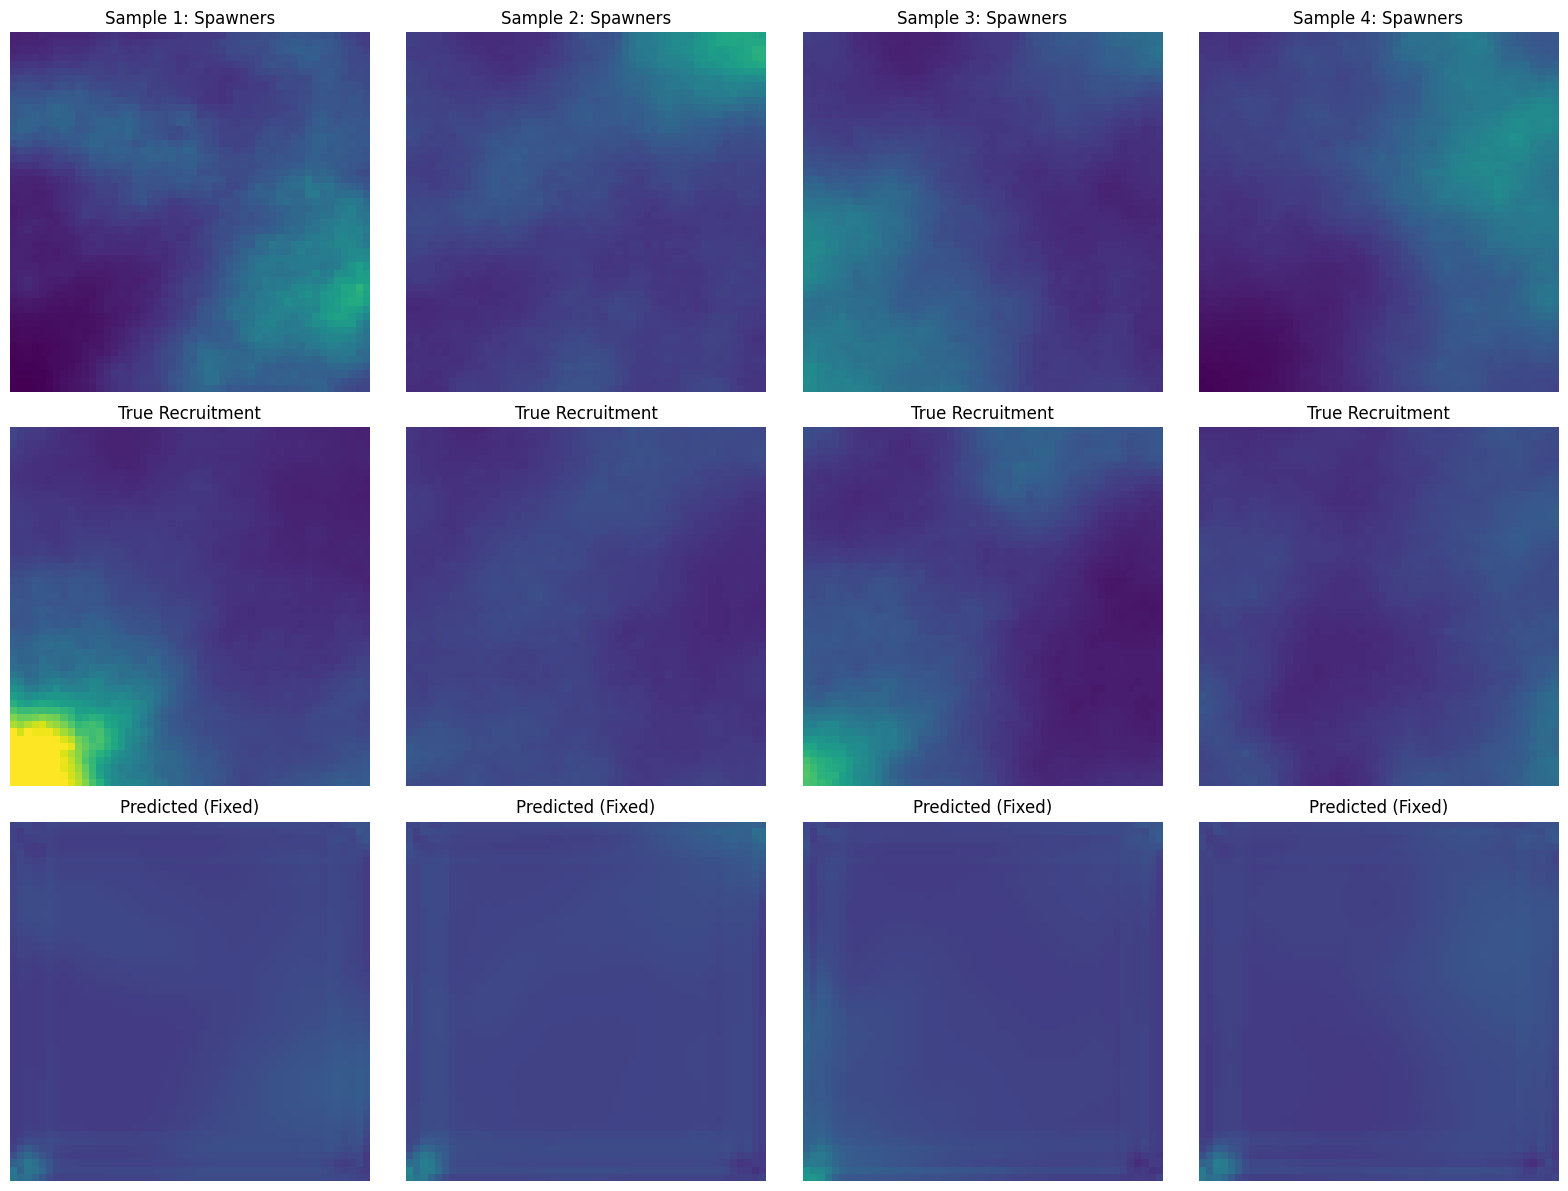

Prediction range: [32.42, 109.52]
Target range: [20.92, 290.45]


In [46]:
# THIS ONE - Run after training completes
import numpy as np
import matplotlib.pyplot as plt


train_spawners = np.load(os.path.join(DATA_PATH, "train_spawners.npy"))
train_recruits = np.load(os.path.join(DATA_PATH, "train_recruits.npy"))
SPAWN_MAX = np.max(train_spawners) + 1e-6
RECRUIT_MAX = np.max(train_recruits) + 1e-6

print(f"Using Constants -> Spawner Max: {SPAWN_MAX:.2f}, Recruit Max: {RECRUIT_MAX:.2f}")


# Load model
checkpoint = torch.load(os.path.join(DATA_PATH, "checkpoints/best_model.pt"))
model = CrabTransformer(
    grid_size=50, patch_size=5, in_channels=1,
    embed_dim=128, num_heads=8, num_layers=6,
    d_ff=512, mask=None, dropout=0.1
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get test data
test_ds = CrabDataset(
    os.path.join(DATA_PATH, "test_spawners.npy"),
    os.path.join(DATA_PATH, "test_recruits.npy"),
    n_years=30,
    normalize=True
)
test_loader = DataLoader(test_ds, batch_size=5, shuffle=False)

# Get predictions
with torch.no_grad():
    inputs, targets, year_indices = next(iter(test_loader))
    inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
    predictions = model(inputs, year_indices)

# Convert to numpy
inputs_np = inputs.cpu().numpy()
targets_np = targets.cpu().numpy()
preds_np = predictions.cpu().numpy()

# Denormalize
#SPAWN_MEAN, SPAWN_STD = 57.3167, 38.3864
#RECRUIT_MEAN, RECRUIT_STD = 49.9369, 24.3599

#inputs_denorm = inputs_np.copy()
#inputs_denorm[:, 0] = inputs_np[:, 0] * SPAWN_STD + SPAWN_MEAN
#inputs_denorm[:, 0] = inputs_np[:, 0] *
#inputs_denorm[:, 1] = inputs_np[:, 1] * RECRUIT_STD + RECRUIT_MEAN

#targets_denorm = targets_np * RECRUIT_STD + RECRUIT_MEAN
#preds_denorm = preds_np * RECRUIT_STD + RECRUIT_MEAN

inputs_denorm = inputs_np.copy()
inputs_denorm[:, 0] = inputs_np[:, 0] * SPAWN_MAX

targets_denorm = targets_np * RECRUIT_MAX
preds_denorm = preds_np * RECRUIT_MAX

# Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(4):
    axes[0, i].imshow(inputs_denorm[i, 0], cmap='viridis', vmin=10, vmax=200)
    axes[0, i].set_title(f'Sample {i+1}: Spawners')
    axes[0, i].axis('off')

    axes[1, i].imshow(targets_denorm[i, 0], cmap='viridis', vmin=10, vmax=200)
    axes[1, i].set_title('True Recruitment')
    axes[1, i].axis('off')

    axes[2, i].imshow(preds_denorm[i, 0], cmap='viridis', vmin=10, vmax=200)
    axes[2, i].set_title('Predicted (Fixed)')
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'checkpoints/predictions_fixed.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Prediction range: [{preds_denorm.min():.2f}, {preds_denorm.max():.2f}]")
print(f"Target range: [{targets_denorm.min():.2f}, {targets_denorm.max():.2f}]")

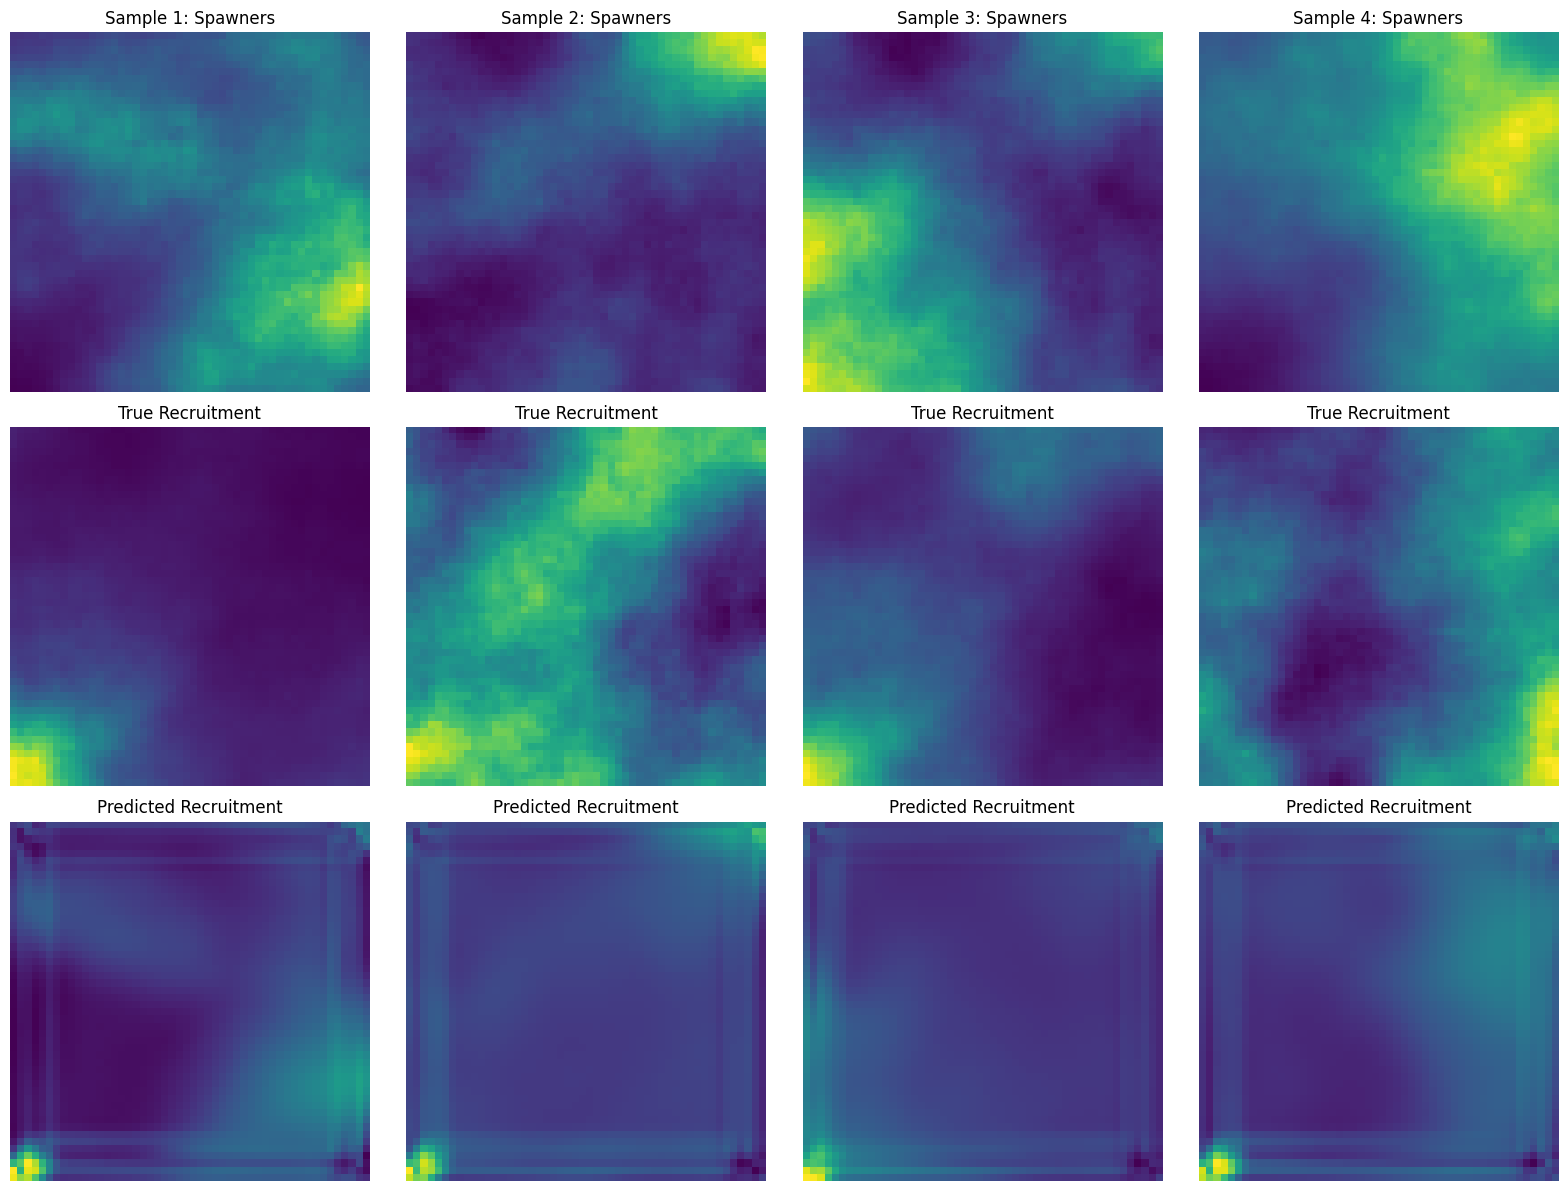

✓ Visualization saved!


In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of predictions
model.eval()
with torch.no_grad():
    # Get first batch from test set
    inputs, targets, year_indices = next(iter(test_loader))
    inputs, targets, year_indices = inputs.to(device), targets.to(device), year_indices.to(device)
    predictions = model(inputs, year_indices)

# Move to CPU and convert to numpy
predictions = predictions.cpu().numpy()
targets = targets.cpu().numpy()
inputs = inputs.cpu().numpy()

# Plot a few examples
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(4):
    # Row 1: Spawner input (channel 0)
    axes[0, i].imshow(inputs[i, 0], cmap='viridis')
    axes[0, i].set_title(f'Sample {i+1}: Spawners')
    axes[0, i].axis('off')

    # Row 2: True recruitment
    axes[1, i].imshow(targets[i, 0], cmap='viridis')
    axes[1, i].set_title('True Recruitment')
    axes[1, i].axis('off')

    # Row 3: Predicted recruitment
    axes[2, i].imshow(predictions[i, 0], cmap='viridis')
    axes[2, i].set_title('Predicted Recruitment')
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'checkpoints/predictions_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualization saved!")

✓ Plot saved to /content/drive/MyDrive/Teleconnection_ViT/checkpoints/training_history.png


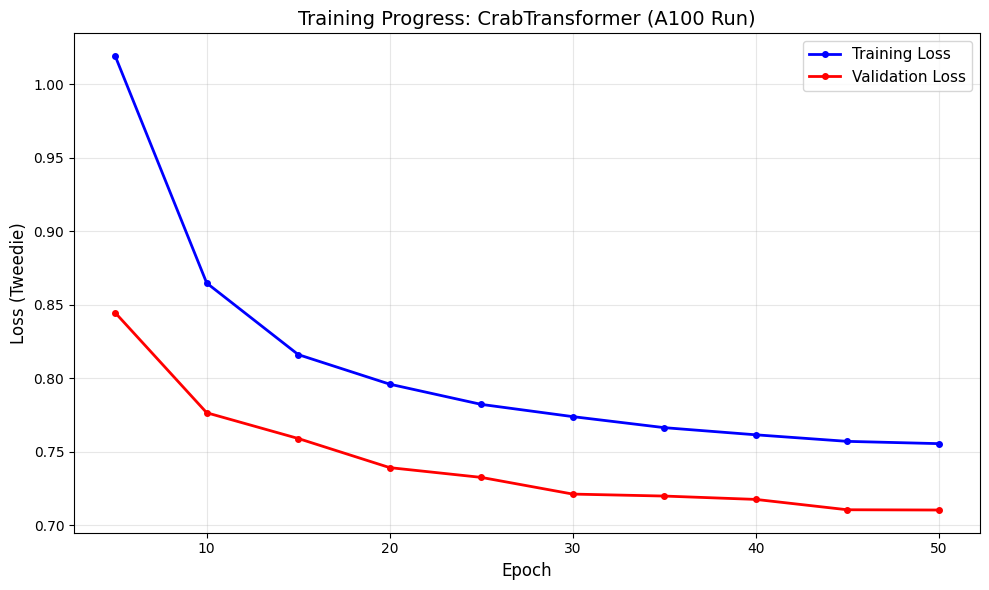

In [48]:
import matplotlib.pyplot as plt
import glob
import re
import numpy as np

# 1. Use a regular expression to extract the number and sort numerically
def get_epoch_num(filename):
    match = re.search(r'epoch_(\d+)', filename)
    return int(match.group(1)) if match else 0

# Load and sort files correctly
checkpoint_files = glob.glob(os.path.join(DATA_PATH, "checkpoints/checkpoint_epoch_*.pt"))
checkpoint_files.sort(key=get_epoch_num) # Sorts 2 before 10

epochs = []
train_losses = []
val_losses = []

for cp_file in checkpoint_files:
    try:
        cp = torch.load(cp_file, map_location='cpu')
        epochs.append(cp['epoch'])
        train_losses.append(cp['train_loss'])
        val_losses.append(cp['val_loss'])
    except Exception as e:
        print(f"Skipping corrupted file {cp_file}: {e}")

# 2. Final safety check: Sort the lists together in case files were messy
# This ensures that even if filenames are weird, the x-axis (epochs) is strictly increasing
sorted_data = sorted(zip(epochs, train_losses, val_losses))
epochs, train_losses, val_losses = zip(*sorted_data)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=4)
plt.plot(epochs, val_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=4)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Tweedie)', fontsize=12)
plt.title('Training Progress: CrabTransformer (A100 Run)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and Show
save_path = os.path.join(DATA_PATH, 'checkpoints/training_history.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✓ Plot saved to {save_path}")
plt.show()

In [49]:

import numpy as np
import matplotlib.pyplot as plt
import torch

# =============================================================================
# FUNCTION 1: Basic Visualization
# =============================================================================

def show_predictions(model, dataloader, device, n_samples=3):
    """
    Show predictions vs ground truth side-by-side.

    Usage:
        show_predictions(model, val_loader, device='cuda', n_samples=3)
    """
    model.eval()

    # Get data
    inputs, targets, year_indices = next(iter(dataloader))
    inputs = inputs[:n_samples].to(device)
    targets = targets[:n_samples].to(device)
    year_indices = year_indices[:n_samples].to(device)

    # Get predictions
    with torch.no_grad():
        preds = model(inputs, year_indices)

    # Move to numpy
    inputs = inputs.cpu().numpy()
    targets = targets.cpu().numpy()
    preds = preds.cpu().numpy()

    # Plot
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

    for i in range(n_samples):
        # Input spawners
        ax = axes[i, 0] if n_samples > 1 else axes[0]
        im = ax.imshow(inputs[i, 0], cmap='viridis')
        ax.set_title('Input: Spawners')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

        # Target
        ax = axes[i, 1] if n_samples > 1 else axes[1]
        im = ax.imshow(targets[i, 0], cmap='plasma')
        ax.set_title('Ground Truth')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

        # Prediction
        ax = axes[i, 2] if n_samples > 1 else axes[2]
        im = ax.imshow(preds[i, 0], cmap='plasma')
        ax.set_title('Prediction')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

        # Error
        ax = axes[i, 3] if n_samples > 1 else axes[3]
        error = preds[i, 0] - targets[i, 0]
        im = ax.imshow(error, cmap='RdBu_r',
                      vmin=-np.abs(error).max(),
                      vmax=np.abs(error).max())
        ax.set_title(f'Error (MAE={np.abs(error).mean():.2f})')
        ax.axis('off')
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

def check_artifacts(model, dataloader, device):
    """
    Check for ring/grid artifacts in decoder output.

    Usage:
        check_artifacts(model, val_loader, device='cuda')
    """
    model.eval()

    # Get one sample
    inputs, targets, year_indices = next(iter(dataloader))
    inputs = inputs[0:1].to(device)
    targets = targets[0:1].to(device)
    year_indices = year_indices[0:1].to(device)

    with torch.no_grad():
        pred = model(inputs, year_indices)

    pred = pred[0, 0].cpu().numpy()
    target = targets[0, 0].cpu().numpy()

    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. Prediction (full)
    ax = axes[0, 0]
    im = ax.imshow(pred, cmap='plasma')
    ax.set_title('Full Prediction\n(Look for rings/patterns)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)

    # 2. Ground truth (full)
    ax = axes[0, 1]
    im = ax.imshow(target, cmap='plasma')
    ax.set_title('Ground Truth\n(Should be smooth)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)

    # 3. Zoomed corner (prediction)
    ax = axes[0, 2]
    zoom = pred[:20, :20]
    im = ax.imshow(zoom, cmap='plasma', interpolation='none')
    ax.set_title('Zoomed Corner\n(Artifacts visible here)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)

    # Add patch grid at boundaries (every 5 pixels = patch size)
    for i in range(0, 20, 5):
        ax.axhline(i-0.5, color='white', linewidth=1, alpha=0.7)
        ax.axvline(i-0.5, color='white', linewidth=1, alpha=0.7)

    # 4. Horizontal slice through middle
    ax = axes[1, 0]
    middle = pred.shape[0] // 2
    ax.plot(pred[middle, :], 'b-', linewidth=2, label='Prediction')
    ax.plot(target[middle, :], 'r--', linewidth=2, alpha=0.7, label='Ground Truth')
    ax.set_title('Horizontal Slice (Middle Row)', fontsize=12)
    ax.set_xlabel('Column')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Mark patch boundaries
    for i in range(0, 50, 5):
        ax.axvline(i, color='gray', linestyle=':', alpha=0.3)

    # 5. Vertical slice through middle
    ax = axes[1, 1]
    middle = pred.shape[1] // 2
    ax.plot(pred[:, middle], 'b-', linewidth=2, label='Prediction')
    ax.plot(target[:, middle], 'r--', linewidth=2, alpha=0.7, label='Ground Truth')
    ax.set_title('Vertical Slice (Middle Column)', fontsize=12)
    ax.set_xlabel('Row')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Mark patch boundaries
    for i in range(0, 50, 5):
        ax.axvline(i, color='gray', linestyle=':', alpha=0.3)

    # 6. Gradient magnitude (shows edges)
    ax = axes[1, 2]
    grad_y = np.abs(np.diff(pred, axis=0, prepend=pred[0:1, :]))
    grad_x = np.abs(np.diff(pred, axis=1, prepend=pred[:, 0:1]))
    grad_mag = np.sqrt(grad_y**2 + grad_x**2)

    im = ax.imshow(grad_mag, cmap='hot')
    ax.set_title('Gradient Magnitude\n(Bright = sharp edges)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Gradient')

    # Overlay patch grid
    for i in range(0, 50, 5):
        ax.axhline(i, color='cyan', linestyle=':', alpha=0.3, linewidth=0.5)
        ax.axvline(i, color='cyan', linestyle=':', alpha=0.3, linewidth=0.5)

    plt.tight_layout()
    plt.show()

    # Print diagnostics
    print("\n" + "="*60)
    print("ARTIFACT DIAGNOSTIC")
    print("="*60)

    # Check if gradients are high at patch boundaries
    boundary_grad = []
    interior_grad = []

    for i in range(pred.shape[0]):
        for j in range(pred.shape[1]):
            # Is this a patch boundary?
            if (i % 5 == 0 or j % 5 == 0) and i > 0 and j > 0 and i < 49 and j < 49:
                boundary_grad.append(grad_mag[i, j])
            elif i % 5 != 0 and j % 5 != 0:
                interior_grad.append(grad_mag[i, j])

    boundary_avg = np.mean(boundary_grad)
    interior_avg = np.mean(interior_grad)

    print(f"Average gradient at patch boundaries: {boundary_avg:.4f}")
    print(f"Average gradient in interior:         {interior_avg:.4f}")
    print(f"Ratio (boundary/interior):            {boundary_avg/interior_avg:.2f}x")

    if boundary_avg > interior_avg * 1.3:
        print("\n⚠️  WARNING: Patch boundaries are visible!")
        print("   Your decoder is creating grid artifacts.")
        print("   Recommendation: Use improved decoder (see below)")
    else:
        print("\n✓ Patch boundaries look smooth!")

    print("="*60)



Training on: cuda
Spawner norm: mean=56.8944, std=36.6632
Recruit norm: mean=49.6799, std=24.0246
Spawner norm: mean=57.3120, std=39.2794
Recruit norm: mean=49.6271, std=23.0386


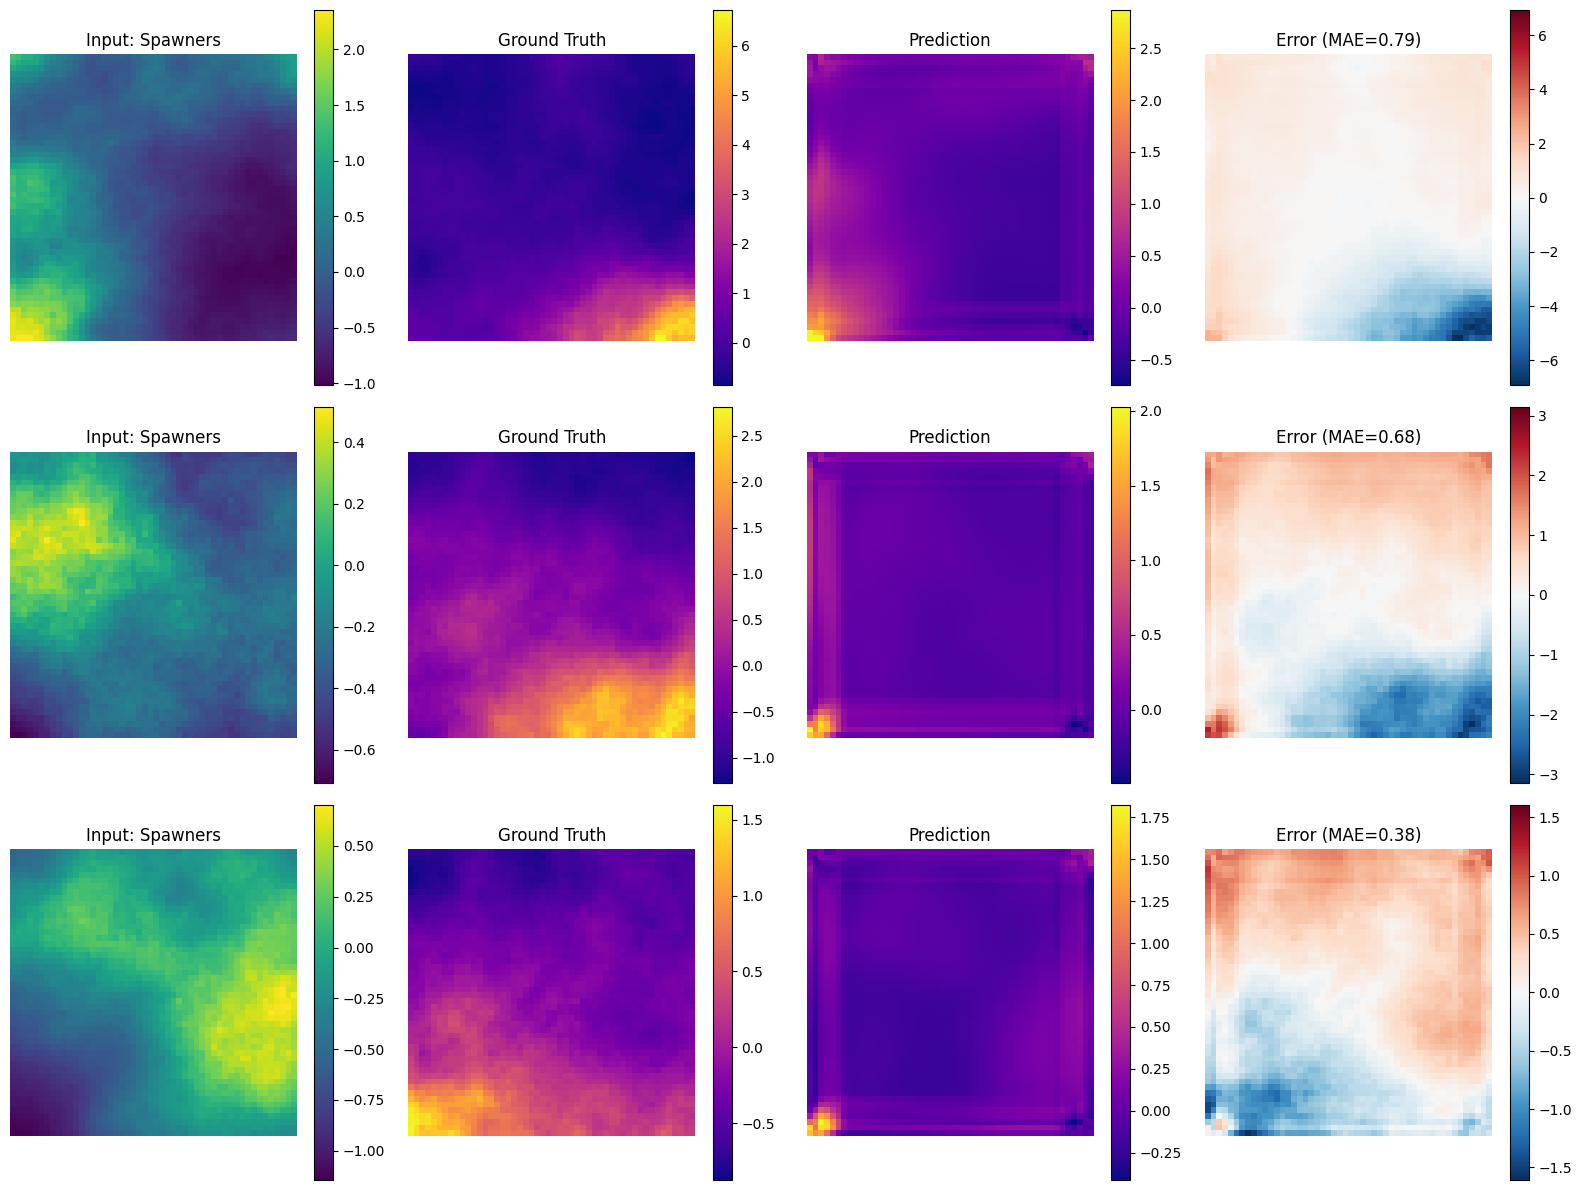

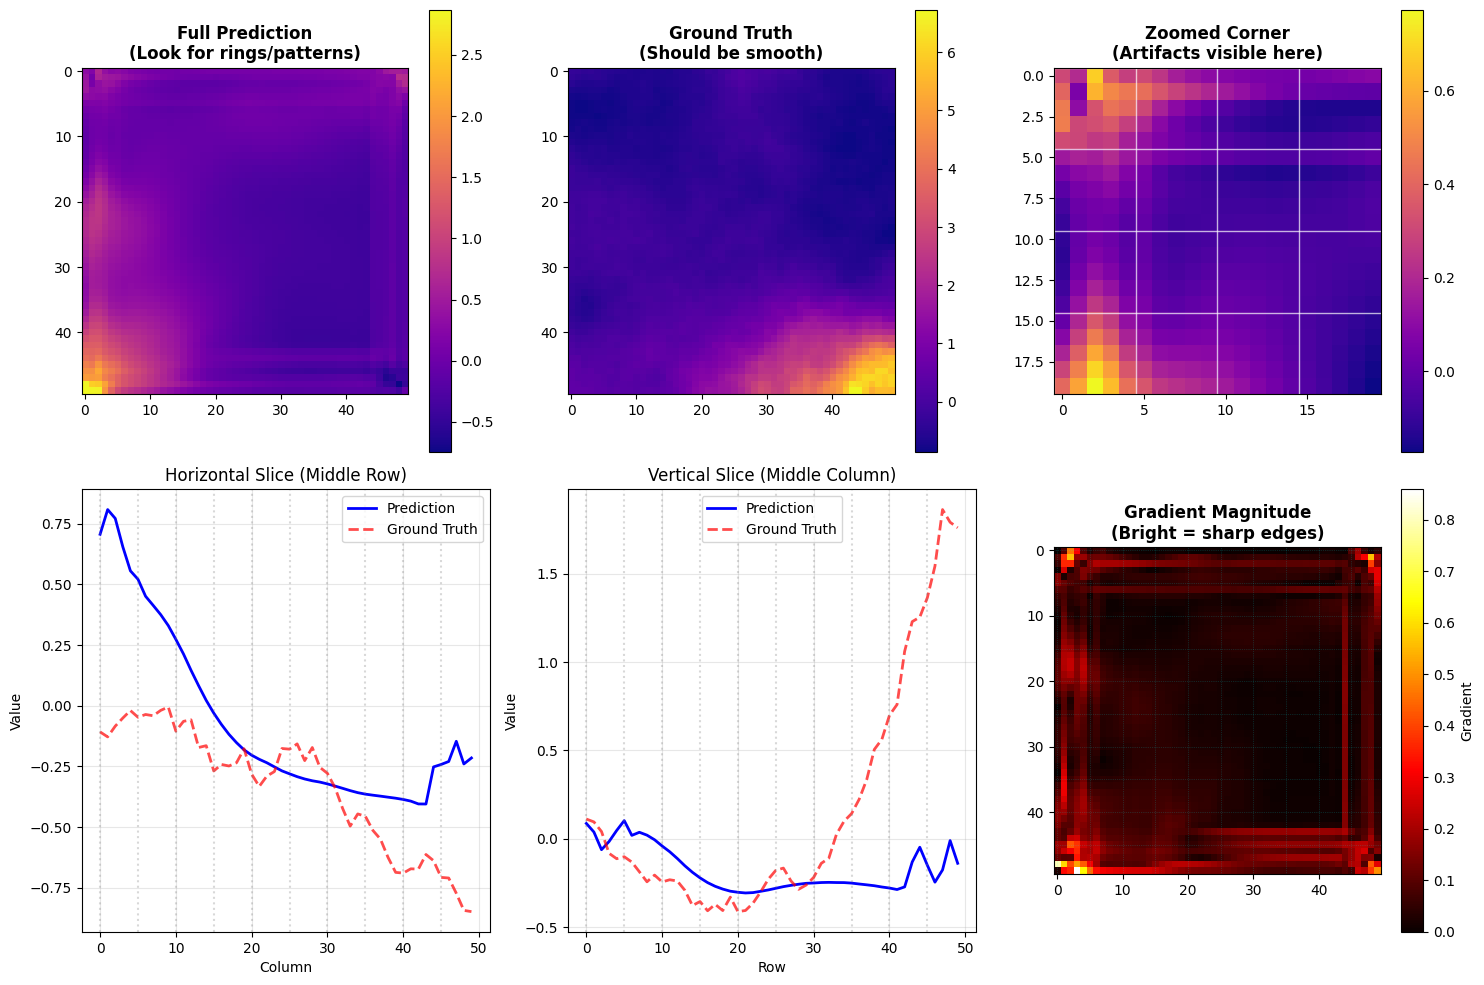


ARTIFACT DIAGNOSTIC
Average gradient at patch boundaries: 0.0527
Average gradient in interior:         0.0676
Ratio (boundary/interior):            0.78x

✓ Patch boundaries look smooth!


In [50]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
batch_size = 5
epochs = 50
learning_rate = 1e-4
grid_size = 50
patch_size = 5
in_channels = 1
embed_dim = 128
num_heads = 8
d_ff = 512
num_layers = 6
mask = None
dropout = 0.1

weight_decay = 1e-5
max_grad_norm = 1



    # prepare data
train_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "train_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "train_recruits.npy"),
        n_years=30
    )

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

val_ds = CrabDataset(
        spawner_path=os.path.join(DATA_PATH, "val_spawners.npy"),
        recruit_path=os.path.join(DATA_PATH, "val_recruits.npy"),
        n_years=30
    )

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


show_predictions(model, val_loader, 'cuda', n_samples=3)
check_artifacts(model, val_loader, 'cuda')